### importing libraries
#### importing LogisticRegression and accuracy score

In [4]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### importing the csv file of the training and testing dataset

In [5]:
X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')
y_train = y_train.squeeze()
y_test = y_test.squeeze()
print(X_train.shape)
print(y_train.shape)


(3212, 29)
(3212,)


### initialising that the model we are doing is logistic regresssion

In [6]:
model = LogisticRegression()

### telling the model to study the training datasets

In [7]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### to predict y(hypertension) using a dataset that is new to the model

In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy_score(y_test, y_pred)

0.9638854296388543

In [10]:
print(y_train.value_counts())

hypertension
0    2422
1     790
Name: count, dtype: int64


### importing lib from sklearn

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [12]:
print(confusion_matrix(y_test, y_pred))

[[592  14]
 [ 15 182]]


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       606
           1       0.93      0.92      0.93       197

    accuracy                           0.96       803
   macro avg       0.95      0.95      0.95       803
weighted avg       0.96      0.96      0.96       803



In [14]:
print(roc_auc_score(y_test, y_pred))

0.9503777788946407


In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [16]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

### plotting the ROC curve

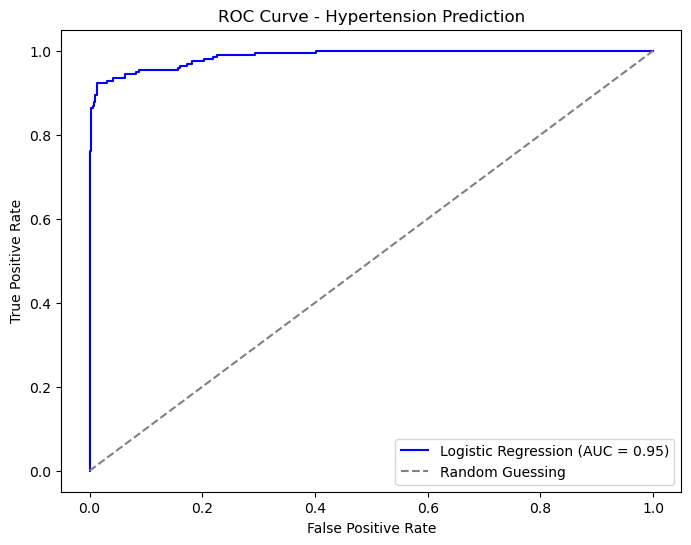

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='Logistic Regression (AUC = 0.95)')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Hypertension Prediction')
plt.legend()
plt.show()

### place the coefficients into a lsit and then assigning it to feature based on column

In [18]:
coefficients = pd.Series(model.coef_[0], index=X_train.columns)
coefficients_sorted = coefficients.sort_values()

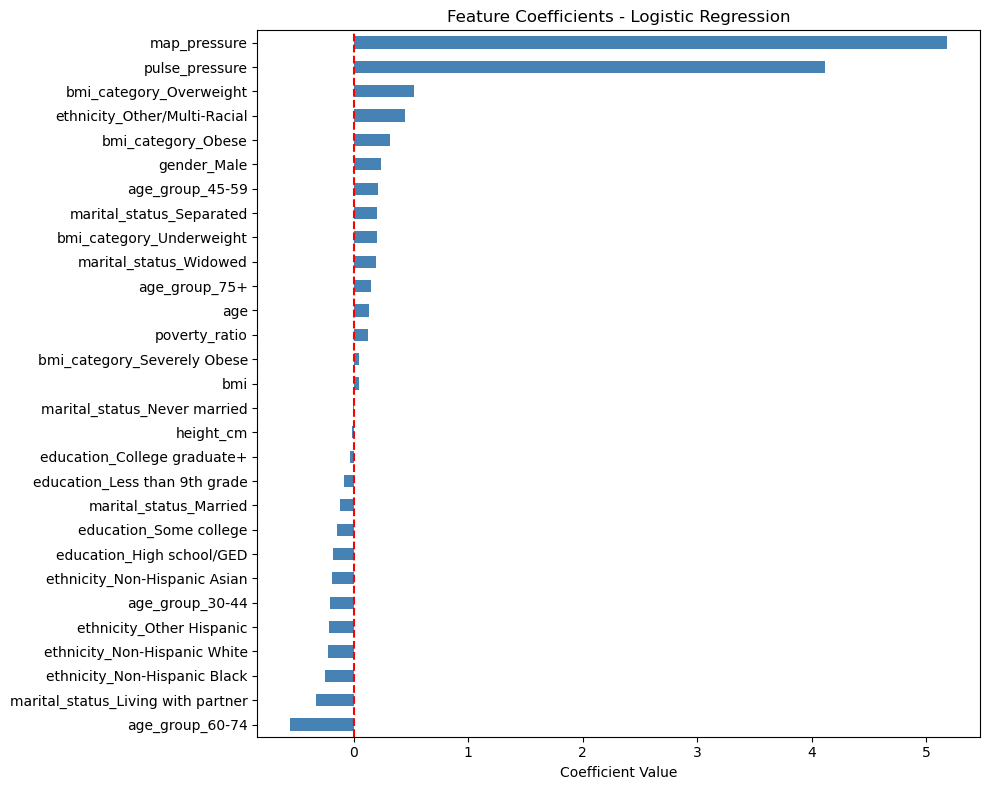

In [19]:
plt.figure(figsize=(10, 8))
coefficients_sorted.plot(kind='barh', color='steelblue')
plt.title('Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### summary 